# Supervised Prediction

In [109]:
### IMPORTS 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display 
plt.style.use('default')

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
 
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split  
from sklearn.model_selection import KFold
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import SplineTransformer
from sklearn.preprocessing import StandardScaler

from statsmodels.nonparametric.kernel_regression import KernelReg
from statsmodels.nonparametric.smoothers_lowess import lowess

In [4]:
### GLOBAL VARS 

RANDOM_SEED = 123

## Gerenate Data

In [5]:
def make_sine_regression_data(n=100, noise=0.35, random_state=123):  # Generate a smooth nonlinear regression data set.
    rng = np.random.default_rng(random_state)  # Create a reproducible random-number generator.
    x = np.sort(rng.uniform(0.0, 3.0, size=n))  # Draw and sort x values for clean smoother plots.
    signal = 4.0 + np.sin(3.0 * x)  # Define a smooth nonlinear mean function.
    y = signal + rng.normal(0.0, noise, size=n)  # Add Gaussian noise around the smooth signal.
    X = x.reshape(-1, 1)  # Reshape x into a sklearn design matrix.
    dat = pd.DataFrame({'x': x, 'y': y, 'truth': signal})  # Store the observed and true curves.
    return X, y, dat  # Return sklearn arrays plus the data frame.

In [27]:
def plot_data(dat, ax, title):  # Define a reusable regression plotting helper.
    order = np.argsort(dat['x'].to_numpy())  # Sort by x so the true curve draws correctly.
    ax.scatter(dat['x'], dat['y'], s=22, alpha=0.60, label='observed')  # Plot noisy observations.
    if 'truth' in dat.columns:  # Check whether the true signal is available.
        ax.plot(dat['x'].to_numpy()[order], dat['truth'].to_numpy()[order], color='red', linewidth=2, label='truth')  # Plot the true mean curve.
    ax.set_title(title)  # Add a short subplot title.
    ax.set_xlabel('x')  # Label the predictor axis.
    ax.set_ylabel('y')  # Label the response axis.
    ax.legend(fontsize=8)  # Show the legend using compact font.

In [28]:
X, y, data = make_sine_regression_data(random_state = RANDOM_SEED)

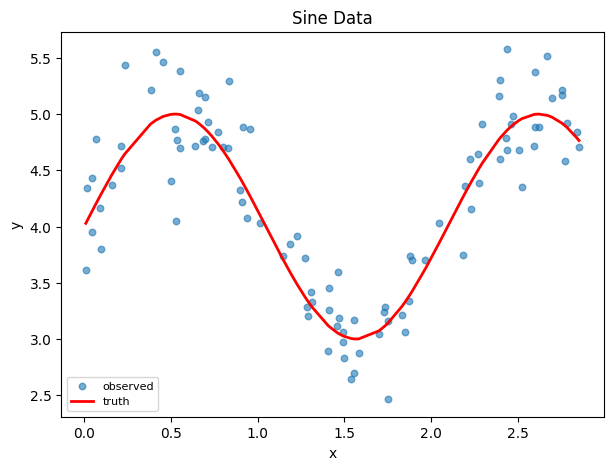

In [29]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))  # Create a grid of regression plots.
# axes_flat = axes.ravel()  # Flatten the axes array for easy looping.
plot_data(data, axes, "Sine Data")

## Experimentation

### Simple Linear Regression Exploration

In [9]:
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)

In [10]:
lr_model = LinearRegression().fit(train_set[['x']], train_set['y'])  

In [11]:
print(lr_model.intercept_)
print(lr_model.coef_[0])

4.2621616163109035
0.01925302023850662


In [12]:
preds = lr_model.predict(test_set[['x']])

In [13]:
preds

array([4.26622501, 4.30157362, 4.30906743, 4.27703818, 4.29584892,
       4.26234535, 4.26391141, 4.29037021, 4.30900549, 4.26344591,
       4.27537131, 4.29776957, 4.30598979, 4.2954235 , 4.27553605,
       4.28684199, 4.3063452 , 4.28417173, 4.29209034, 4.30585513])

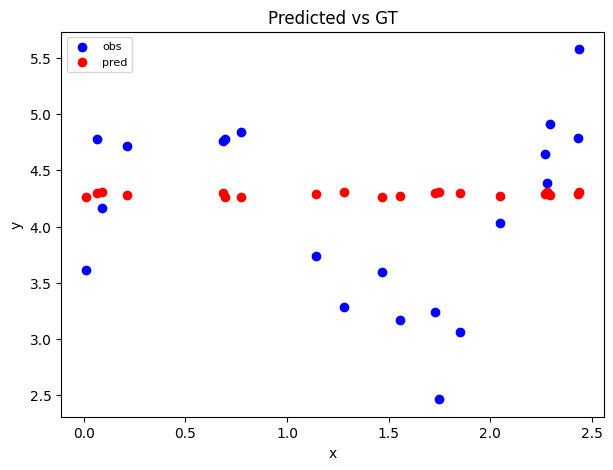

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))  # Create a grid of regression plots.
# axes_flat = axes.ravel()  # Flatten the axes array for easy looping.
order = np.argsort(test_set['x'].to_numpy())  # Sort by x so the true curve draws correctly.
axes.scatter(test_set['x'], test_set['y'], color='blue', label='obs')  # Plot noisy observations.
axes.scatter(test_set['x'].to_numpy()[order], preds, color='red', label='pred')  # Plot the true mean curve.
# axes.plot(test_set['x'].to_numpy()[order], preds, color='red', label='pred', linewidth=2)  # Plot the true mean curve.
axes.set_title('Predicted vs GT')  # Add a short subplot title.
axes.set_xlabel('x')  # Label the predictor axis.
axes.set_ylabel('y')  # Label the response axis.
axes.legend(fontsize=8)  # Show the legend using compact font.

### Polynomial Feature Exploration

In [15]:
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)

In [16]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [47]:
loo = LeaveOneOut()

In [17]:
# Degree 3 -> y = b0 + b1x + b2x² + b3x³
pr_model = make_pipeline(PolynomialFeatures(degree=3, include_bias=False), LinearRegression())

In [18]:
kfold_mse = -cross_val_score(pr_model, X, y, cv=kfold, scoring='neg_mean_squared_error')
kfold_mse

array([0.39779865, 0.20876633, 0.30491519, 0.36455432, 0.42083109])

In [19]:
float(np.average(kfold_mse))

0.3393731159617358

In [20]:
kfold_preds = cross_val_predict(pr_model, X, y, cv=kfold)
kfold_preds

array([4.67931165, 4.60294961, 4.52758802, 4.552191  , 4.72484554,
       4.74010996, 4.68536571, 4.61781694, 4.78314283, 4.64510633,
       4.63418152, 4.76717101, 4.62975641, 4.58822864, 4.72318828,
       4.55069756, 4.70580448, 4.651557  , 4.52925614, 4.55519894,
       4.62110427, 4.47591559, 4.44363796, 4.53846329, 4.52970403,
       4.53516116, 4.55365161, 4.37515788, 4.44533893, 4.33625442,
       4.42877229, 4.29829955, 4.3228292 , 4.21469115, 4.187351  ,
       4.18042896, 4.25332956, 4.20501475, 3.98632007, 3.87914608,
       3.83958952, 3.79642214, 3.81820934, 3.85849438, 3.83929754,
       3.83198782, 3.71521861, 3.71199694, 3.66292149, 3.66333981,
       3.62727765, 3.66729672, 3.6055309 , 3.59440033, 3.64177674,
       3.5907871 , 3.55395609, 3.57624831, 3.5522737 , 3.51259375,
       3.46268053, 3.50697073, 3.47894763, 3.45669766, 3.51285799,
       3.44812126, 3.46116848, 3.46187681, 3.4639059 , 3.53038523,
       3.53313376, 3.82575836, 3.75270017, 3.75289028, 3.81768

In [21]:
mse = mean_squared_error(y, kfold_preds)
mse

0.33937311596173586

In [48]:
loo_mse = -cross_val_score(pr_model, X, y, cv=loo, scoring='neg_mean_squared_error')
loo_mse

array([1.15629042e+00, 6.45034217e-02, 3.35940147e-02, 5.11672930e-01,
       3.40038069e-02, 2.59503387e-01, 8.20779517e-01, 1.07309850e-01,
       6.12343090e-04, 3.46909704e-02, 5.94080496e-01, 2.84559639e-01,
       7.96920532e-01, 6.70499653e-01, 6.16233917e-02, 5.80130607e-02,
       3.63786018e-01, 2.36595615e-02, 6.35610286e-01, 8.18265763e-03,
       3.08967435e-02, 2.70949474e-01, 4.69428780e-01, 6.85609223e-02,
       8.62701289e-02, 4.59485753e-01, 2.17491810e-01, 6.54859847e-02,
       1.91906233e-01, 1.04969238e-01, 1.22083754e-01, 9.50677747e-01,
       2.21577058e-03, 2.88844999e-03, 4.13840636e-01, 2.66103521e-02,
       4.61725484e-01, 1.21966596e-02, 6.20777297e-02, 7.64818670e-03,
       7.50163848e-04, 1.30903956e-02, 3.08372218e-01, 3.87662140e-01,
       1.48573919e-01, 2.19401636e-01, 6.70280359e-01, 1.96353587e-01,
       5.59884941e-02, 2.97776643e-01, 2.11198283e-03, 2.11262091e-01,
       4.38484654e-01, 3.25024253e-01, 6.49870706e-01, 9.28791650e-01,
      

In [49]:
float(np.average(loo_mse))

0.34273573999068346

### Kernel Smoothers Exploration

In [33]:
train_set, test_set = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)

In [34]:
# Fit kernel smoother
kr = KernelReg(
    exog=train_set['x'],       # predictor variable
    endog=train_set['y'],      # response variable
    var_type="c",        # "c" means continuous predictor
    reg_type="lc"        # "lc" = local constant kernel regression
)

In [39]:
preds, slope_est = kr.fit(test_set['x'])

In [73]:
order = np.argsort(test_set['x'].to_numpy())

x_test_sorted = test_set['x'].to_numpy()[order]
y_test_sorted = test_set['y'].to_numpy()[order]
preds_sorted = preds[order]

In [74]:
mean_squared_error(y_test_sorted, preds_sorted)

0.13319196901591046

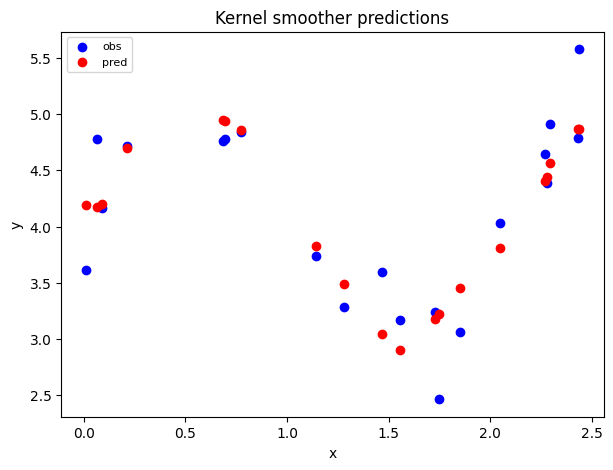

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(test_set['x'], test_set['y'], color='blue', label='obs')
plt.scatter(x_test_sorted, preds_sorted, color='red', label='pred')

plt.title('Kernel smoother predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(fontsize=8)
plt.show()

## Building Functions for Testing Each Method

### Polynomial Regression

In [ ]:
def fit_poly_reg(X, y, cv_type, deg, k=5, seed=RANDOM_SEED):
    
    cv = None
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    model = make_pipeline(
        PolynomialFeatures(degree=deg, include_bias=False), 
        LinearRegression()
    )
    
    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return float(np.average(mse_vals))


In [117]:
fit_poly_reg(X, y, "kfold", 3)

0.3393731159617358

### Splines

In [ ]:
def fit_spline(X, y, cv_type, n_knots,  k=5, seed=RANDOM_SEED, deg=3):

    cv = None
    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    model = make_pipeline(
        SplineTransformer(n_knots=n_knots, degree=deg, include_bias=False), 
        LinearRegression()
    )

    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return float(np.average(mse_vals))


In [65]:
fit_spline(X, y, "kfold", 3)

0.1253390070598247

### Lasso

In [114]:
def fit_lasso(X, y, cv_type, alpha, k=5, seed=RANDOM_SEED, max_iter = 10000):

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha, max_iter=max_iter)
    )

    mse_vals = -cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")

    return float(np.average(mse_vals))

In [115]:
fit_lasso(X, y, "kfold", 0.1,)

0.6670524321993764

### Kernel Smoothers

In [83]:
def kernel_weights(u, kernel_type):

    abs_u = np.abs(u)

    if kernel_type == "epanechnikov":
        # K(u) = 0.75 * (1 - u^2), for |u| <= 1
        return np.where(abs_u <= 1, 0.75 * (1 - u**2), 0.0)

    elif kernel_type == "gaussian":
        # K(u) = exp(-0.5u^2), ignoring the normalizing constant
        return np.exp(-0.5 * u**2)

    elif kernel_type == "tricube":
        # K(u) = (1 - |u|^3)^3, for |u| <= 1
        return np.where(abs_u <= 1, (1 - abs_u**3)**3, 0.0)

    elif kernel_type == "uniform":
        # K(u) = 1, for |u| <= 1
        return np.where(abs_u <= 1, 1.0, 0.0)

    else:
        raise ValueError(
            "kernel_type must be one of: "
            "'epanechnikov', 'gaussian', 'tricube', or 'uniform'"
        )

In [84]:
def nadaraya_watson_predict(x_train, y_train, x_test, bandwidth, kernel_type="epanechnikov"):
    """
    Nadaraya-Watson kernel smoother prediction.

    For each test point x0:

        y_hat(x0) = sum_i K((x_i - x0) / bandwidth) * y_i
                    --------------------------------------
                    sum_i K((x_i - x0) / bandwidth)
    """

    x_train = np.asarray(x_train).reshape(-1)
    y_train = np.asarray(y_train).reshape(-1)
    x_test = np.asarray(x_test).reshape(-1)

    x_sorted = np.sort(x_train)
    mean_spacing = np.mean(np.diff(x_sorted))
    bandwidth = bandwidth * mean_spacing

    preds = np.empty(len(x_test))

    for j, x0 in enumerate(x_test):
        u = (x_train - x0) / bandwidth
        weights = kernel_weights(u, kernel_type)

        if np.sum(weights) == 0:
            # Fallback: if no points fall inside a compact-support kernel window,
            # use the closest training point's y-value.
            nearest_idx = np.argmin(np.abs(x_train - x0))
            preds[j] = y_train[nearest_idx]
        else:
            preds[j] = np.sum(weights * y_train) / np.sum(weights)

    return preds

In [85]:
def fit_ksmooth(X, y, cv_type, bandwidth, kernel_type="epanechnikov", k=5, seed=RANDOM_SEED):

    X = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    mse_vals = []

    for train_idx, test_idx in cv.split(X):
        x_train = X[train_idx]
        y_train = y[train_idx]

        x_test = X[test_idx]
        y_test = y[test_idx]

        preds = nadaraya_watson_predict(
            x_train=x_train,
            y_train=y_train,
            x_test=x_test,
            bandwidth=bandwidth,
            kernel_type=kernel_type
        )

        mse_vals.append(mean_squared_error(y_test, preds))

    return float(np.mean(mse_vals))

In [100]:
fit_ksmooth(X, y, 'kfold', 10)

0.12694606116953283

### Loess/Lowess

In [103]:
def fit_loess(X, y, cv_type, span, k=5, seed=RANDOM_SEED, it=0):

    X = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)

    if cv_type == "kfold":
        cv = KFold(n_splits=k, shuffle=True, random_state=seed)
    elif cv_type == "loo":
        cv = LeaveOneOut()
    else:
        raise ValueError("cv_type must be either 'kfold' or 'loo'")

    mse_vals = []

    for train_idx, test_idx in cv.split(X):
        x_train = X[train_idx]
        y_train = y[train_idx]

        x_test = X[test_idx]
        y_test = y[test_idx]

        preds = lowess(
            endog=y_train,
            exog=x_train,
            frac=span,
            it=it,
            xvals=x_test
        )

        mse_vals.append(mean_squared_error(y_test, preds))

    return float(np.mean(mse_vals))

In [105]:
fit_loess(X, y, "kfold", .1)

0.13089155012803638